In [18]:
import pandas as pd
from sqlalchemy import create_engine

# Configuration de la connexion PostgreSQL
db_config = {
    'host': 'localhost',
    'database': 'minecraft_stats',
    'user': 'minecraft_stats',
    'password': 'minecraft_stats',
}

# Chaîne de connexion SQLAlchemy
conn_str = f"postgresql+psycopg2://{db_config['user']}:{db_config['password']}@" \
           f"{db_config['host']}/{db_config['database']}"

# Création de l'engine
engine = create_engine(conn_str)


In [19]:
query = """
SELECT ss.id, ss.server_id, ss.player_count, ss.max_count, ss.created_at, s.name
FROM server_stats ss
JOIN servers s ON ss.server_id = s.id
ORDER BY ss.created_at DESC
LIMIT 100
"""

df = pd.read_sql(query, engine)
df.head()


,id,server_id,player_count,max_count,created_at,name
0,8784189,30,0.0,300.0,2025-07-21 11:04:17.687000+00:00,PixelCube
1,8784188,237,167.0,2000.0,2025-07-21 11:04:17.032000+00:00,Regorland
2,8784187,31,84.0,500.0,2025-07-21 11:04:15.106000+00:00,VikingCraft
3,8784186,238,26.0,25000.0,2025-07-21 11:04:13.867000+00:00,McManhunt
4,8784185,32,NaN,NaN,2025-07-21 11:04:12.567000+00:00,LordingQuest


date
2025-07-21    15699.0
Name: player_count, dtype: float64


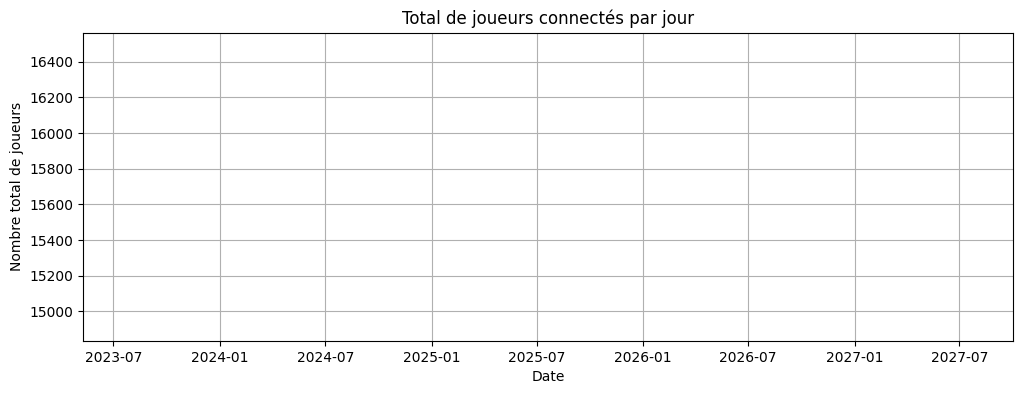

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Conversion de la date
df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')
df['player_count'] = pd.to_numeric(df['player_count'], errors='coerce')

# Nettoyage
df = df.dropna(subset=['created_at', 'player_count'])

# Ajout colonne date (sans heure)
df['date'] = df['created_at'].dt.date

# Agrégation
daily_total = df.groupby('date')['player_count'].sum()

# Vérification rapide
print(daily_total.tail())

# Affichage graphique
daily_total.plot(figsize=(12, 4), title="Total de joueurs connectés par jour")
plt.xlabel("Date")
plt.ylabel("Nombre total de joueurs")
plt.grid()
plt.show()


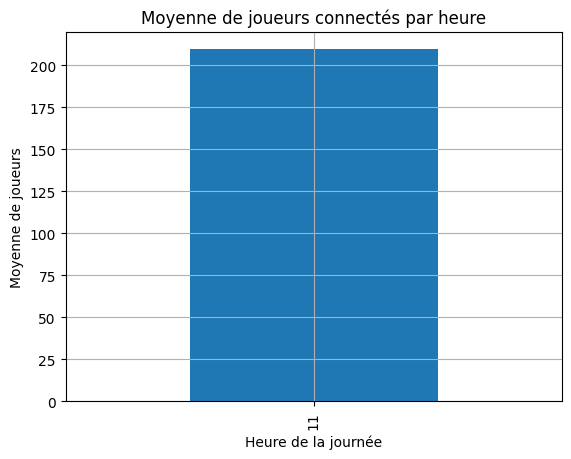

In [21]:
df['hour'] = df['created_at'].dt.hour
hourly_avg = df.groupby('hour')['player_count'].mean()

hourly_avg.plot(kind='bar', title="Moyenne de joueurs connectés par heure")
plt.xlabel("Heure de la journée")
plt.ylabel("Moyenne de joueurs")
plt.grid()
plt.show()

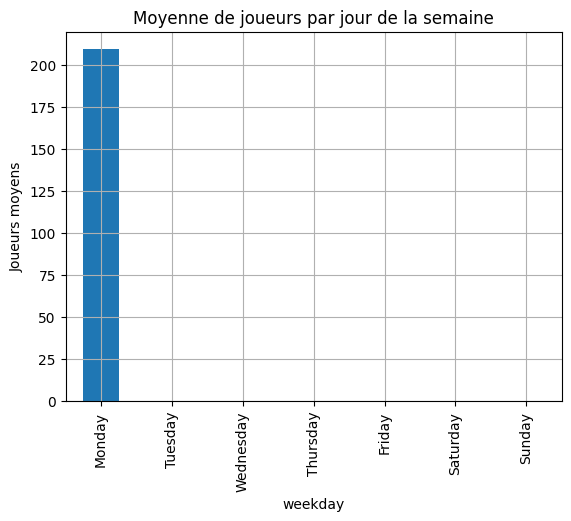

In [22]:
df['weekday'] = df['created_at'].dt.day_name()
weekday_avg = df.groupby('weekday')['player_count'].mean().reindex([
    "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"
])

weekday_avg.plot(kind='bar', title="Moyenne de joueurs par jour de la semaine")
plt.ylabel("Joueurs moyens")
plt.grid()
plt.show()

         date  total_players
0  2024-06-05       26393379
1  2024-06-06       27384067
2  2024-06-07       29464226
3  2024-06-08       33719157
4  2024-06-09       34716997


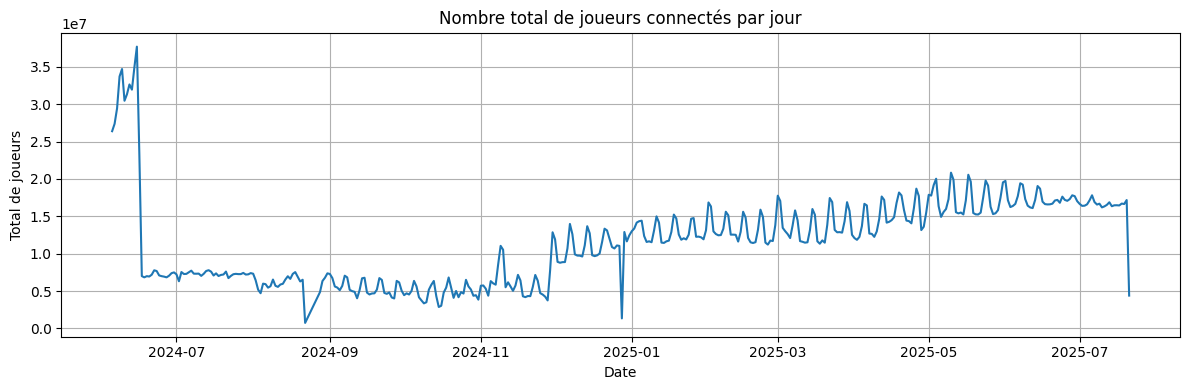

In [23]:
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt

# Configuration de la connexion PostgreSQL
db_config = {
    'host': 'localhost',
    'database': 'minecraft_stats',
    'user': 'minecraft_stats',
    'password': 'minecraft_stats',
}

# Connexion SQLAlchemy
conn_str = f"postgresql+psycopg2://{db_config['user']}:{db_config['password']}@" \
           f"{db_config['host']}/{db_config['database']}"
engine = create_engine(conn_str)

# Requête SQL : somme des joueurs par jour
query = """
SELECT DATE(created_at) AS date, SUM(player_count) AS total_players
FROM server_stats
WHERE player_count IS NOT NULL
GROUP BY DATE(created_at)
ORDER BY DATE(created_at)
"""

# Exécution de la requête et chargement dans un DataFrame
df = pd.read_sql(query, engine)

# Affichage d'un aperçu
print(df.head())

# Visualisation
plt.figure(figsize=(12, 4))
plt.plot(df['date'], df['total_players'])
plt.title("Nombre total de joueurs connectés par jour")
plt.xlabel("Date")
plt.ylabel("Total de joueurs")
plt.grid(True)
plt.tight_layout()
plt.show()
